# Newscast analysis — deliverable

Newscast side of the project, built on the shared segmentation engine (`newscast_engine.py`) and the
candidate/party + poll tables in `Project_Features`. Newscasts carry only two modalities — dense **OCR**
(every second) and **sparse speech** (EuroLLM transcript embeddings) — so everything below is read from those.

- **Task 2 — single newscast (`Telejornal_RTP_Nov_10`):** (a) where the broadcast hands off from the anchor
  to each news story; (b) the topics it covered, how many distinct news, and for how long; then a check of
  whether *one* modality alone would suffice to characterise the broadcast.
- **Task 3 — multi-video (all 14 newscasts):** the topic mix across every transmission, the same story on
  both channels (RTP vs TVI), candidate/party coverage vs the polls, poll & coverage volatility, whether news
  *topics* track poll moves, whether newscasts echo the debates, and whether coverage can predict poll evolution.

## Setup

In [1]:
import re, glob, math, warnings
from datetime import date
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

pd.set_option('display.max_colwidth', 60); warnings.filterwarnings('ignore')
FEATURES_DIR = 'Project_Features'
SHARED_DAYS = ['Nov_10', 'Nov_20', 'Dec_2', 'Dec_11', 'Dec_18', 'Jan_6']   # days with BOTH RTP and TVI
MATCH_MIN = 0.55
RANDOM_STATE = 42

MONTHS = {'Oct': (2025, 10), 'October': (2025, 10), 'Nov': (2025, 11), 'November': (2025, 11),
          'Dec': (2025, 12), 'December': (2025, 12), 'Jan': (2026, 1), 'January': (2026, 1),
          'Feb': (2026, 2), 'February': (2026, 2)}
def day_to_date(s):
    mon, d = s.split('_'); y, m = MONTHS[mon]; return date(y, m, int(d))

CANDIDATE_ALIASES = {
    'Gouveia_Melo': ['gouveia e melo', 'gouveia melo', 'henrique gouveia', 'almirante gouveia'],
    'Marques_Mendes': ['marques mendes', 'luís marques mendes', 'luis marques mendes', 'marques-mendes'],
    'Seguro': ['antónio josé seguro', 'antonio jose seguro', 'josé seguro', 'jose seguro', 'seguro'],
    'Ventura': ['andré ventura', 'andre ventura', 'ventura'],
    'Cotrim_Figueiredo': ['cotrim figueiredo', 'joão cotrim', 'joao cotrim', 'cotrim'],
    'Filipe': ['antónio filipe', 'antonio filipe'],
    'Martins': ['catarina martins', 'martins'],
    'Pinto': ['jorge pinto', 'pinto'],
}
CANDS = list(CANDIDATE_ALIASES)
def scan_candidates(text):
    low = str(text).lower()
    return {c for c, al in CANDIDATE_ALIASES.items() if any(a in low for a in al)}


Setup ready.


## Segmentation engine

The newscast segmentation pipeline lives in `newscast_engine.py` (the shared module also used by the Task 2 / Task 3 notebooks) and is imported here as `ns`. It segments each broadcast into news items from the two modalities the newscasts actually carry — **OCR** (dense, every second) and **speech** (EuroLLM transcript embeddings).

In [2]:
import newscast_engine as ns


Segmentation engine imported from newscast_engine.py


### Load — segment every newscast once

Run the segmentation pipeline over all 14 broadcasts, embed each news item (mean EuroLLM transcript
embedding), and tag channel / day / date and any candidates named in it. Everything below reuses this.

In [3]:
all_ns = sorted(re.sub(r'_speech.pkl$', '', p.split('/')[-1])
                for p in glob.glob(f'{FEATURES_DIR}/Telejornal_*_speech.pkl'))
seg = ns.run_newscast_engine(
    ns.SegmentationConfig(features_dir=FEATURES_DIR), videos=all_ns)
items = seg['newscast_items'].copy()
sp = ns.load_speech(FEATURES_DIR, all_ns)
items['emb'] = [ns.item_embedding_for_interval(sp[sp.video == r.video], r.start_s, r.end_s)
                for r in items.itertuples()]
items['channel'] = items['video'].str.extract(r'Telejornal_(RTP|TVI)_')
items['day'] = items['video'].str.extract(r'Telejornal_(?:RTP|TVI)_(.+)$')
items['date'] = items['day'].map(day_to_date)
def _itext(r):
    sv = sp[sp.video == r.video]; m = (sv.start_s < r.end_s) & (sv.end_s > r.start_s)
    return f"{r.headline or ''} " + ' '.join(sv.loc[m, 'transcript'].astype(str))
items['item_text'] = [_itext(r) for r in items.itertuples()]
items['cands'] = items['item_text'].map(scan_candidates)


743 news items across 14 newscasts on 8 dates


### Helpers — news-type classification & the topic bar chart

In [4]:
# --- News-type classification (keyword rules on headline + transcript) ---
NEWS_TYPE_KEYWORDS = {
    'politics': ['greve', 'governo', 'parlamento', 'eleições', 'eleicoes', 'presidenciais', 'candidato',
                 'candidata', 'campanha', 'comício', 'comicio', 'votar', 'voto', 'partido', 'primeiro-ministro',
                 'primeiro ministro', 'ministro', 'ministério', 'ministerio', 'sondagem', 'assembleia'],
    'international': ['trump', 'ucrânia', 'ucrania', 'rússia', 'russia', 'gaza', 'israel', 'palestina', 'eua',
                     'estados unidos', 'putin', 'biden', 'nato', 'europa', 'angola', 'brasil', 'china',
                     'venezuela', 'irão', 'irao'],
    'economy': ['inflação', 'inflacao', 'pensões', 'pensoes', 'salário', 'salario', 'salários', 'salarios',
                'banco', 'preços', 'precos', 'crise', 'orçamento', 'orcamento', 'imposto', 'irs', 'iva', 'desemprego'],
    'sports': ['futebol', 'liga', 'selecção', 'seleccao', 'seleção', 'selecao', 'jogo', 'apuramento',
               'benfica', 'porto', 'sporting', 'mundial', 'campeonato', 'jogador'],
    'society': ['saúde', 'saude', 'hospital', 'sns', 'escola', 'educação', 'educacao', 'crime', 'tribunal',
                'pj', 'polícia', 'policia', 'incêndio', 'incendio', 'imigração', 'imigracao', 'protesto',
                'manifestação', 'manifestacao'],
    'culture': ['cinema', 'festival', 'concerto', 'teatro', 'museu', 'livro', 'web summit', 'exposição', 'exposicao', 'arte'],
    'weather': ['tempo', 'chuva', 'frio', 'calor', 'temperatura', 'previsão', 'previsao', 'tempestade', 'vento'],
}
NEWS_TYPE_COLORS = {'politics': '#1f77b4', 'international': '#d62728', 'economy': '#2ca02c', 'sports': '#ff7f0e',
                    'society': '#9467bd', 'culture': '#8c564b', 'weather': '#17becf', 'other': '#7f7f7f'}

def classify_news_type(text):
    t = str(text).lower()
    scores = {nt: sum(1 for kw in kws if kw in t) for nt, kws in NEWS_TYPE_KEYWORDS.items()}
    best = max(scores, key=scores.get)
    return best if scores[best] > 0 else 'other'


# Task 2 — single newscast: `Telejornal_RTP_Nov_10`

The brief asks two things of one broadcast: **(a)** when the scene moves from the anchor to each news story,
and **(b)** the topics, the number of distinct news, and their length. We take (a) first — it gives the story
boundaries — then (b), and finally ask whether one modality alone would have been enough.

## Goal (a) — on-screen news stories & the anchor → news hand-offs

Goal (a) asks *when the broadcast moves from the anchor to a news story*. There is **no face/visual stream**
for newscasts, so we read this from the **OCR story-headline graphics**: each story is announced from the
studio and then carries a sustained lower-third headline strap. We detect those **sustained story straps** —
their **onsets are the anchor → news hand-offs**, and the spans between them are studio links / cutaways with
no story graphic. We then cross-check this OCR-native story count against the multimodal segmentation.

In [5]:
FRAME_W, FRAME_H = 1280, 720
CHANNEL_CHROME_CX_MIN, ZONE_LOWER_MAIN_WIDTH_FRAC = 0.72, 0.25
ZONE_ORDER = ['top', 'middle', 'lower_third_sub', 'lower_third_main', 'narrow_lower', 'channel_chrome', 'clock_bar']
def classify_zone(cx, cy, w):
    if cy < 0.20: return 'top'
    if cy < 0.70: return 'middle'
    if cy < 0.83: return 'lower_third_sub'
    if cy < 0.93:
        if cx >= CHANNEL_CHROME_CX_MIN: return 'channel_chrome'
        return 'lower_third_main' if w > ZONE_LOWER_MAIN_WIDTH_FRAC else 'narrow_lower'
    return 'clock_bar'
def ocr_zoned(video):
    o = seg['ocr'][seg['ocr'].video == video].dropna(subset=['time_s']).copy()
    cx = (o['x_center'] / FRAME_W).clip(0, 1); cy = (o['y_center'] / FRAME_H).clip(0, 1)
    w = ((o['x2'] - o['x1']) / FRAME_W).clip(0, 1)
    o['zone'] = [classify_zone(a, b, c) for a, b, c in zip(cx, cy, w)]
    o['sec'] = o['time_s'].round().astype(int)
    return o

def _sustained_headlines(video, dur_min=12, obs_min=4):
    # the engine's stable lower-third headline intervals, kept only if well-sustained
    h = seg['headline_intervals']
    return h[(h.video == video) & (h.duration_s >= dur_min) & (h.observations >= obs_min)].sort_values('start_s')

def story_straps(video, dur_min=12, obs_min=4, gap=20, min_block=12):
    # ONE on-screen news story = a CONTIGUOUS block of story-strap presence (bridging gaps <= `gap` s).
    # The strap TEXT changes within a story (main headline -> name/location super -> updated line), while
    # a studio link (no strap) separates stories. So we count blocks, not distinct texts (which over-counts
    # one story as several). Each block's label = its longest-airtime real headline.
    h = _sustained_headlines(video, dur_min, obs_min)
    if h.empty:
        return pd.DataFrame(columns=['onset', 'end_s', 'strap_s', 'parts', 'headline'])
    blocks = []
    for r in h.itertuples():
        if blocks and r.start_s - blocks[-1]['end_s'] <= gap:
            b = blocks[-1]; b['end_s'] = max(b['end_s'], r.end_s); b['parts'].append((r.headline, r.duration_s))
        else:
            blocks.append(dict(onset=r.start_s, end_s=r.end_s, parts=[(r.headline, r.duration_s)]))
    rows = []
    for b in blocks:
        if b['end_s'] - b['onset'] + 1 < min_block:
            continue
        real = [(hl, d) for hl, d in b['parts'] if hl and hl != 'NO OCR HEADLINE' and ' / ' not in hl]
        rows.append(dict(onset=b['onset'], end_s=b['end_s'], strap_s=round(sum(d for _, d in b['parts'])),
                         parts=len(b['parts']), headline=max(real or b['parts'], key=lambda x: x[1])[0]))
    return pd.DataFrame(rows).sort_values('onset').reset_index(drop=True)

def graphic_mask(video, end, dur_min=12, obs_min=4):
    # per-second mask of when a sustained story graphic is ACTUALLY on screen (union of detected seconds)
    g = np.zeros(end + 1, dtype=bool)
    for r in _sustained_headlines(video, dur_min, obs_min).itertuples():
        g[int(max(0, r.start_s)):int(min(r.end_s, end)) + 1] = True
    return g

FOCUS = 'Telejornal_RTP_Nov_10'
oz = ocr_zoned(FOCUS)
chrome = oz.loc[oz.zone == 'channel_chrome', 'clean_text'].astype(str)
clock = oz.loc[oz.zone == 'clock_bar', 'text'].astype(str)
straps = story_straps(FOCUS)


OCR zone sanity (channel-dependent persistent overlays, NOT used as the anchor signal):
  channel_chrome rows naming the channel/programme : 70%
  clock_bar rows matching a clock pattern           : 86%

Telejornal_RTP_Nov_10: 21 on-screen news stories (contiguous story-graphic blocks, merging the 48 raw strap texts within them)


,onset,end_s,strap_s,parts,headline
0,7.0,19.0,12,1,"PM E A GREVE ""INTERESSES PARTIDÁRIOS"""
1,46.0,62.0,16,1,SELECÃO NACIONAL A 1 JOGO DO APURAMENTO
2,101.0,115.0,14,1,GREVE GERAL
3,138.0,150.0,12,1,CGTP DIZ QUE PM VIVE NUMA REALIDADE ENVIESADA
4,200.0,223.0,23,1,GREVE GERAL
5,325.0,374.0,49,1,BUSCAS NAZARÉ
6,449.0,470.0,21,1,TRABALHADORES COM FILHOS ATÉ 12 ANOS 📭
7,526.0,697.0,148,8,GOVERNO QUER CONTINUAR A NEGOCIAR COM SINDICATOS
8,802.0,817.0,15,1,CANDIDATO DIZ QUE HÁ INTERFERÊNCIA NAS ELEICÕES
9,861.0,1014.0,116,5,CAMPANHA PRESIDENCIAL


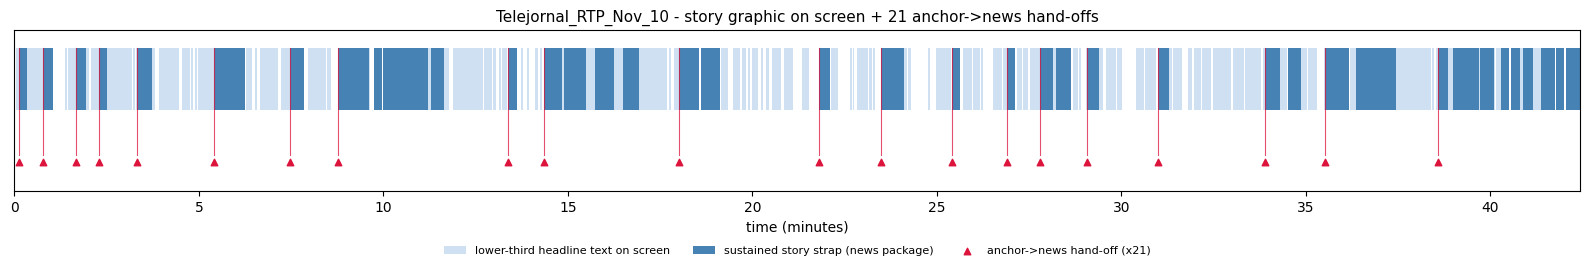

21 distinct news stories (hand-offs).
  lower-third headline text on screen : 83% of airtime
  sustained main story strap          : 40% of airtime
  no lower-third headline at all       : 17% (anchor/studio reads & raw B-roll)
  => most airtime carries SOME lower-third headline text, but only
     ~40% of it is a SUSTAINED main story strap (the strict "story graphic on screen" measure).


In [6]:
# Timeline: where a story graphic is on screen, and the anchor->news hand-offs (story-strap onsets).
end = int(math.ceil(ns.infer_video_end_s(sp[sp.video == FOCUS], seg['ocr'][seg['ocr'].video == FOCUS])))
sustained = graphic_mask(FOCUS, end)                           # sustained main story strap (dur>=12, obs>=4)
any_strap = graphic_mask(FOCUS, end, dur_min=0, obs_min=0)     # ANY non-boilerplate lower-third headline text

def _runs(mask):
    out, i = [], 0
    while i <= end:
        if mask[i]:
            j = i
            while j <= end and mask[j]:
                j += 1
            out.append((i, j - i)); i = j
        else:
            i += 1
    return out

fig, ax = plt.subplots(figsize=(16, 3.0))
ax.broken_barh(_runs(any_strap), (1.0, 0.7), facecolors='#cfe0f3', label='lower-third headline text on screen')
ax.broken_barh(_runs(sustained), (1.0, 0.7), facecolors='steelblue', label='sustained story strap (news package)')
for o in straps['onset']:
    ax.plot([o, o], [0.5, 1.7], color='crimson', lw=0.8, alpha=0.75)
ax.scatter(straps['onset'], [0.42] * len(straps), marker='^', color='crimson', s=22, zorder=5,
           label=f'anchor->news hand-off (x{len(straps)})')
ax.set_ylim(0.1, 1.9); ax.set_yticks([]); ax.set_xlim(0, end)
ax.set_xticks(range(0, end + 1, 300)); ax.set_xticklabels([f'{t // 60}' for t in range(0, end + 1, 300)])
ax.set_xlabel('time (minutes)')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.28), ncol=3, fontsize=8, frameon=False)
ax.set_title(f'{FOCUS} - story graphic on screen + {len(straps)} anchor->news hand-offs', fontsize=11)
plt.tight_layout(); plt.show()


In [7]:
# Tag each segmented news item by whether a story graphic actually covers it, and cross-check the counts.
gmask = graphic_mask(FOCUS, end)
def covered_frac(r):
    a, b = int(max(0, r.start_s)), int(min(r.end_s, len(gmask) - 1))
    return gmask[a:b + 1].mean() if b > a else 0.0
its = items[items.video == FOCUS].copy()
its['on_screen_story'] = [covered_frac(r) >= 0.30 for r in its.itertuples()]
its['segment_type'] = np.where(its['on_screen_story'], 'news package (graphic)', 'studio / link / B-roll')


Telejornal_RTP_Nov_10: multimodal engine items = 45 | OCR distinct on-screen stories = 21
  engine items carrying a story graphic: 22 | studio/link items: 23
  (the engine over-segments long reports; the deduped OCR story count is a more parsimonious 'how many stories' signal)


,item_id,start_s,duration_s,segment_type,headline
194,1,0.000,46.000,studio / link / B-roll,"PM E A GREVE ""INTERESSES PARTIDÁRIOS"""
195,2,46.000,52.000,news package (graphic),SELECÃO NACIONAL A 1 JOGO DO APURAMENTO
196,3,98.000,52.000,news package (graphic),GREVE GERAL
197,4,150.000,35.000,studio / link / B-roll,REGISTRO / RE
198,5,185.000,39.000,news package (graphic),GREVE GERAL
199,6,224.000,39.000,studio / link / B-roll,OPERACÃO DUNAS
200,7,263.000,42.000,studio / link / B-roll,POLÍCIA JUDICIÁRIA FEZ BUSCAS NA C.M. DA NAZARÉ
201,8,305.000,72.000,news package (graphic),BUSCAS NAZARÉ
202,9,377.000,45.000,studio / link / B-roll,LIMITAR DISPENSA DE AMAMENTACÃO ATÉ AOS 2 ANOS
203,10,422.000,55.000,news package (graphic),TRABALHADORES COM FILHOS ATÉ 12 ANOS 📭


**How to read this, honestly.** With no face/visual stream we can't see the anchor directly, so we detect the **story-headline graphic** instead. A sustained lower-third strap's onset is a reliable *anchor → news* hand-off; the *no story graphic* spans mix true studio links with graphic-less package footage (B-roll, interviews), so they are **not** a clean \"anchor-only\" measure. The count is **distinct stories** (a topic shown at the top and recapped later is merged into one), and the coverage % uses the **actually-detected seconds** the strap is on screen (not the onset→end span) — so both are honest lower bounds, not the inflated raw numbers.

## Goal (b) — topics across the news, count & length

Each news item is classified by keyword rules into politics / international / economy / sports / society /
culture / weather (else *other*) on its headline + transcript. The bar below is the airtime (minutes) and
item count per news type; the count of **distinct on-screen stories** is the goal-(a) figure above.

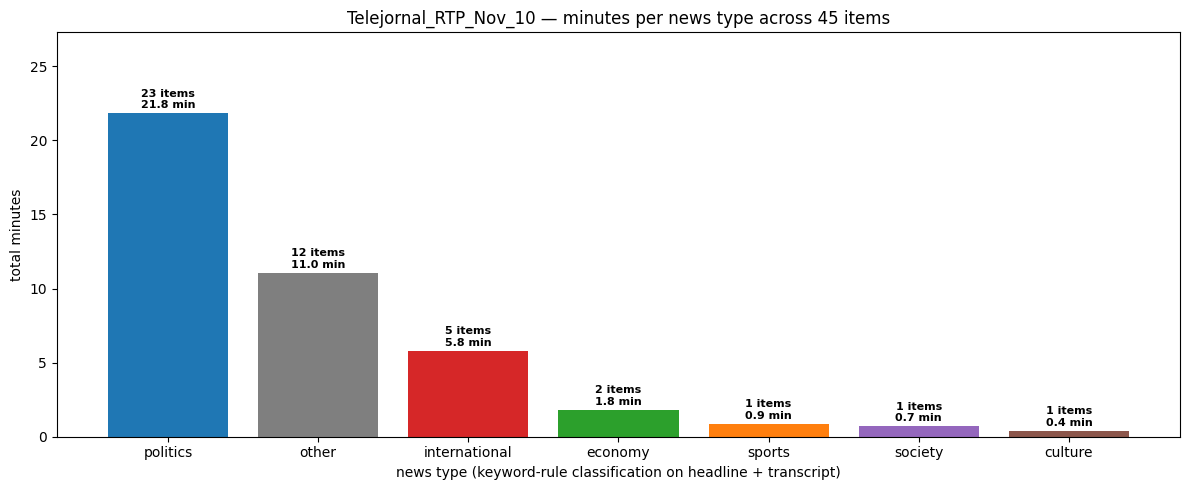

In [8]:
# Goal (b): minutes of airtime per news type in the chosen broadcast.
src_df = items[items.video == 'Telejornal_RTP_Nov_10']
TITLE = f'Telejornal_RTP_Nov_10 — minutes per news type across {len(src_df)} items'
nt = src_df.copy()
nt['news_type'] = nt['item_text'].map(classify_news_type)
summ = (nt.groupby('news_type')
        .agg(items=('item_id', 'count'), total_minutes=('duration_s', lambda s: s.sum() / 60.0))
        .sort_values('total_minutes', ascending=False).reset_index())
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(summ['news_type'], summ['total_minutes'],
       color=[NEWS_TYPE_COLORS.get(t, 'gray') for t in summ['news_type']])
for i, r in summ.iterrows():
    ax.text(i, r['total_minutes'] + 0.2, f"{int(r['items'])} items\n{r['total_minutes']:.1f} min",
            ha='center', va='bottom', fontsize=8, weight='bold')
ax.set_ylabel('total minutes')
ax.set_xlabel('news type (keyword-rule classification on headline + transcript)')
ax.set_title(TITLE); ax.set_ylim(0, summ['total_minutes'].max() * 1.25)
plt.tight_layout(); plt.show()


## Is one modality enough to characterise the videos?

The brief asks this directly. Newscasts give two modalities — dense **OCR** (every second) and **sparse speech** (EuroLLM transcript embeddings on only part of the timeline). Below we ablate each: first for **segmentation** (can a single modality find the news-item boundaries?), then for **topic characterisation** (do speech-only and OCR-only clusterings agree?).

In [9]:
from sklearn.metrics import adjusted_rand_score
SIG_KEYS = ['semantic_shift', 'ocr_headline_shift', 'ocr_layout_shift']
def _signals(video):
    sv = sp[sp.video == video]; ov = seg['ocr'][seg['ocr'].video == video]
    hv = seg['headline_intervals'][seg['headline_intervals'].video == video]
    cfg = ns.SegmentationConfig(features_dir=FEATURES_DIR)
    end = ns.infer_video_end_s(sv, ov, hv); n = int(math.ceil(end)) + 1
    S = {k: np.zeros(n) for k in SIG_KEYS}
    ns._place_points(S['semantic_shift'], ns.compute_semantic_shift(sv, cfg.semantic_window_segments))
    ns._place_points(S['ocr_headline_shift'], [(float(r.start_s), 1.0) for r in hv.itertuples() if float(r.start_s) > cfg.min_item_duration_s])
    ns._place_points(S['ocr_layout_shift'], ns.compute_ocr_layout_shift(ov))
    for k in S: S[k] = np.maximum(ns.normalize_signal(S[k]), ns.smooth_signal(ns.normalize_signal(S[k]), radius=2))
    return S, hv, sv, end, cfg
def boundaries_modality(video, modality):
    S, hv, sv, end, cfg = _signals(video)
    if modality == 'speech':                                   # semantic shift only; OCR fully suppressed
        Sz = {k: (S['semantic_shift'] if k == 'semantic_shift' else np.zeros_like(S[k])) for k in SIG_KEYS}
        return ns.select_boundaries(S['semantic_shift'].copy(), Sz, pd.DataFrame(columns=ns.HEADLINE_COLUMNS), sv, end, cfg)
    w = {'ocr_headline_shift': 0.25, 'ocr_layout_shift': 0.15}; tot = sum(w.values())   # OCR signals only
    Sz = {k: (np.zeros_like(S[k]) if k == 'semantic_shift' else S[k]) for k in SIG_KEYS}
    return ns.select_boundaries(sum(w[k] / tot * S[k] for k in w), Sz, hv, pd.DataFrame(columns=['start_s']), end, cfg)
def recovered(ref, test, tol=10.0): return sum(any(abs(r - t) <= tol for t in test) for r in ref)
_ar = []
for v in all_ns:
    comb = sorted(seg['newscast_boundaries'].query('video == @v')['boundary_s'].tolist())
    sb, ob = boundaries_modality(v, 'speech'), boundaries_modality(v, 'ocr')
    sv = sp[sp.video == v]; e = ns.infer_video_end_s(sv, seg['ocr'][seg['ocr'].video == v])
    _ar.append(dict(video=v.replace('Telejornal_', ''), combined=len(comb), speech_only=len(sb), ocr_only=len(ob),
                    speech_recall=round(recovered(comb, sb) / max(len(comb), 1), 2),
                    ocr_recall=round(recovered(comb, ob) / max(len(comb), 1), 2),
                    speech_visibility=round(sv['duration'].sum() / max(e, 1), 2)))
ablation = pd.DataFrame(_ar)


,video,combined,speech_only,ocr_only,speech_recall,ocr_recall,speech_visibility
0,RTP_Dec_11,56,19,57,0.23,0.84,0.45
1,RTP_Dec_18,25,4,26,0.08,0.88,0.23
2,RTP_Dec_2,57,16,58,0.16,0.82,0.46
3,RTP_Jan_13,60,27,60,0.30,0.88,0.42
4,RTP_Jan_6,55,16,57,0.15,0.87,0.36
5,RTP_Nov_10,52,15,54,0.23,0.88,0.31
6,RTP_Nov_20,55,15,52,0.18,0.75,0.34
7,TVI_Dec_11,80,40,76,0.29,0.70,0.58
8,TVI_Dec_18,78,36,80,0.26,0.79,0.52
9,TVI_Dec_2,102,59,104,0.36,0.72,0.61


On average OCR alone recovers 80% of the combined boundaries; speech alone 26% — and speech can only 'see' 45% of the timeline (the rest carries no transcript).


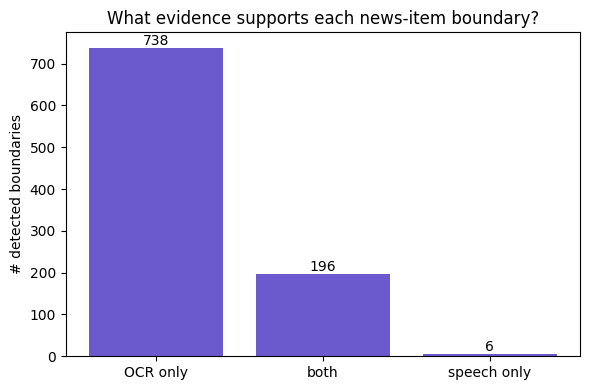

In [10]:
def _ev(f):
    s = {x for x in str(f).split(',') if x}; o = bool(s & {'ocr_headline', 'ocr_layout'}); m = 'semantic' in s
    return 'both' if o and m else 'OCR only' if o else 'speech only' if m else 'other'
cats = seg['newscast_boundaries']['evidence_flags'].map(_ev).value_counts()
fig, ax = plt.subplots(figsize=(6, 4)); ax.bar(cats.index, cats.values, color='slateblue')
for i, val in enumerate(cats.values): ax.text(i, val, str(val), ha='center', va='bottom')
ax.set_ylabel('# detected boundaries'); ax.set_title('What evidence supports each news-item boundary?')
plt.tight_layout(); plt.show()

In [11]:
# Topic characterisation with ONE modality: speech embeddings vs OCR-headline text
emb_mask = items['emb'].apply(lambda x: isinstance(x, np.ndarray)).values
hl = items['headline'].fillna('NO OCR HEADLINE'); ocr_mask = (hl != 'NO OCR HEADLINE').values
k = min(10, max(2, round(math.sqrt(emb_mask.sum()))))
def _km(M):
    M = M - M.mean(0); M = M / (np.linalg.norm(M, axis=1, keepdims=True) + 1e-9)
    return KMeans(k, n_init=10, random_state=RANDOM_STATE).fit_predict(M)
sp_lab = np.full(len(items), -1); sp_lab[emb_mask] = _km(np.vstack(items.loc[emb_mask, 'emb'].values).astype(float))
ocr_lab = np.full(len(items), -1)
Xo = TfidfVectorizer(max_features=2000, stop_words=list(ns.PT_STOPWORDS), strip_accents='unicode').fit_transform(hl[ocr_mask]).toarray()
ocr_lab[ocr_mask] = KMeans(k, n_init=10, random_state=RANDOM_STATE).fit_predict(Xo)
both = emb_mask & ocr_mask


743 news items | invisible to SPEECH (no transcript): 178 (24%) | invisible to OCR (no headline): 0 (0%)
speech-topics vs OCR-topics agreement (adjusted Rand on 565 co-labelled items): -0.00

Verdict - neither modality alone is sufficient, and they are asymmetric:
  - OCR (dense) recovers the broadcast STRUCTURE and covers 100% of the timeline, but its short headlines barely cluster into topics;
  - speech (sparse) carries the topic MEANING, but only on the ~25-64% of airtime it transcribes.
  The two clusterings hardly agree (low ARI): each captures a different facet, so the combined view above is what answers "what aired, and for how long".


# Task 3 — multi-video analysis (all 14 newscasts)

Task 2 looked at one broadcast; Task 3 works across all 14. From the brief: which topics dominated the
two-month window, whether the **same story runs on both channels** (and when), what coverage says about the
**candidates and their parties** vs the polls, how volatile support and coverage were, whether news **topics**
(not just names) track poll moves, whether newscasts **echo the debates**, and whether coverage can **predict
poll evolution**.

## News-type mix across all 14 transmissions

The same news-type breakdown (goal b) pooled over every broadcast.

**News type across all transmissions** — the same keyword-rule classification over every newscast.

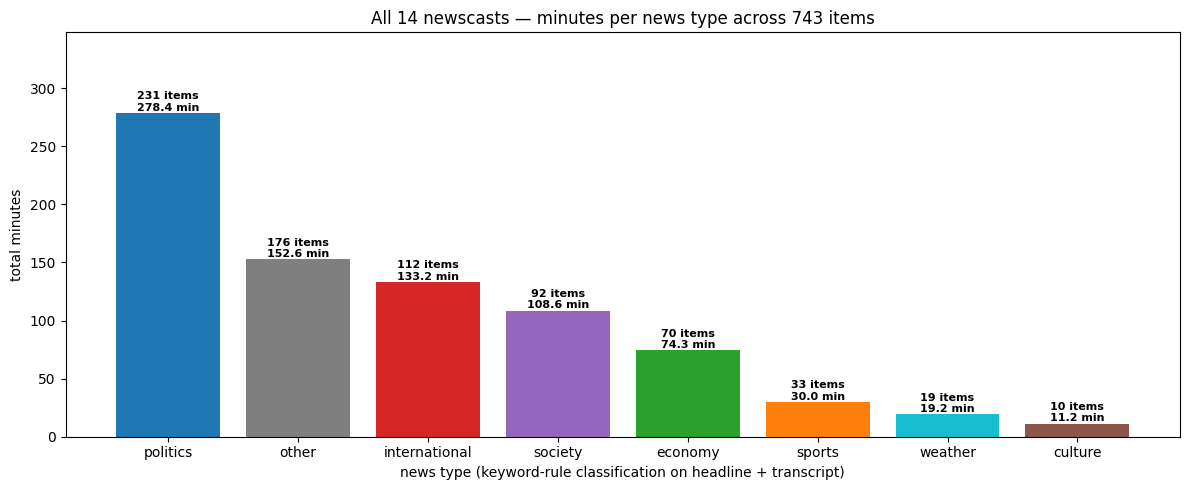

In [12]:
# Same news-type breakdown pooled over all 14 broadcasts.
src_df = items
TITLE = f'All {items.video.nunique()} newscasts — minutes per news type across {len(items)} items'
nt = src_df.copy()
nt['news_type'] = nt['item_text'].map(classify_news_type)
summ = (nt.groupby('news_type')
        .agg(items=('item_id', 'count'), total_minutes=('duration_s', lambda s: s.sum() / 60.0))
        .sort_values('total_minutes', ascending=False).reset_index())
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(summ['news_type'], summ['total_minutes'],
       color=[NEWS_TYPE_COLORS.get(t, 'gray') for t in summ['news_type']])
for i, r in summ.iterrows():
    ax.text(i, r['total_minutes'] + 0.2, f"{int(r['items'])} items\n{r['total_minutes']:.1f} min",
            ha='center', va='bottom', fontsize=8, weight='bold')
ax.set_ylabel('total minutes')
ax.set_xlabel('news type (keyword-rule classification on headline + transcript)')
ax.set_title(TITLE); ax.set_ylim(0, summ['total_minutes'].max() * 1.25)
plt.tight_layout(); plt.show()


## On-screen story structure across all 14 broadcasts

The goal-(a) story-strap detector applied to **every** broadcast — how many distinct on-screen stories each
carried, and what share of airtime showed a story graphic (RTP vs TVI). *(Extends the single-newscast view in
Task 2 goal (a) to the whole corpus.)*

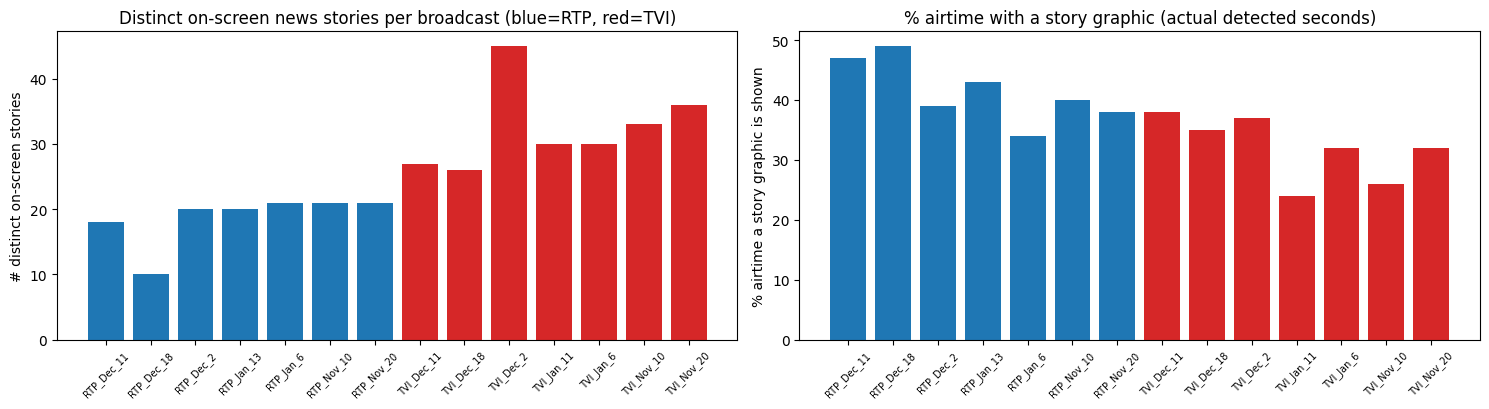

         minutes  stories  graphic_pct
channel                               
RTP         43.6     18.7         41.4
TVI         71.9     32.4         32.0


In [13]:
# Across all 14 broadcasts: distinct on-screen story count and % airtime a story graphic is actually shown.
_sr = []
for v in all_ns:
    e = int(math.ceil(ns.infer_video_end_s(sp[sp.video == v], seg['ocr'][seg['ocr'].video == v])))
    _sr.append(dict(video=v.replace('Telejornal_', ''), channel='RTP' if 'RTP' in v else 'TVI',
                    minutes=round(e / 60), stories=len(story_straps(v)),
                    graphic_pct=round(graphic_mask(v, e).mean() * 100)))
strap_summary = pd.DataFrame(_sr)
fig, ax = plt.subplots(1, 2, figsize=(15, 4.2))
col = ['#1f77b4' if c == 'RTP' else '#d62728' for c in strap_summary.channel]
ax[0].bar(strap_summary.video, strap_summary.stories, color=col); ax[0].set_ylabel('# distinct on-screen stories')
ax[0].tick_params(axis='x', rotation=45, labelsize=7); ax[0].set_title('Distinct on-screen news stories per broadcast (blue=RTP, red=TVI)')
ax[1].bar(strap_summary.video, strap_summary.graphic_pct, color=col); ax[1].set_ylabel('% airtime a story graphic is shown')
ax[1].tick_params(axis='x', rotation=45, labelsize=7); ax[1].set_title('% airtime with a story graphic (actual detected seconds)')
plt.tight_layout(); plt.show()


## Same story on both channels — RTP vs TVI airtime

On the days both channels were recorded, each RTP item is matched to its mutual-nearest-neighbour TVI
item (centered-cosine ≥ 0.55 = "same story"). We then compare how much airtime each channel gave it
and which channel ran it earlier.

34 cross-channel story matches across 6 shared days
(142 RTP items checked — 34 mutual NN pairs, 34 above threshold 0.55)


,day,sim,rtp_headline,tvi_headline,aired_first
0,Dec_11,0.989,GREVE GERAL,GREVE: ENSINO PARALISADO,RTP
1,Dec_11,0.989,ÚLTIMA HORA,GREVE GERAL EM TODO O PAÍS,TVI
2,Dec_11,0.988,GREVE GERAL,GREVE: TRANSPORTES PARALISADOS,RTP
3,Dec_11,0.984,GREVE GERAL,GREVE GERAL EM TODO O PAÍS,RTP
4,Dec_11,0.982,EDUCACÃO E SAÚDE TAMBÉM AFETADOS ESTA 6ª FEIRA,"""ACABAR COM A GUERRA DEVIA SER OBJETIVO DA UE""",RTP
5,Dec_11,0.979,"""VAI AUMENTAR AINDA MAIS A PRECARIEDADE""",PACOTE LABORAL AINDA ESTÁ EM CONCERTACÃO SOCIAL,RTP
6,Dec_18,0.972,PGR RESPONDE A MONTENEGRO,CASO SPINUMVIVA ARQUIVADO,RTP
7,Dec_18,0.971,"ATIVOS RUSSOS ""CONGELADOS""",LÍDERES DA UE DEBATEM FINANCIAMENTO À UCRÂNIA,RTP
8,Dec_18,0.970,"""ESFORCO DA ALTICE NÃO TEM SIDO O QUE PRECISAMOS""",PONTOS NEGROS NAS ESTRADAS,RTP
9,Dec_18,0.964,PORTO X FAMALICÃO ÀS 20H45 NA RTP,"GOUVEIA E MELO NÃO QUER ""POLÍTICOS EM LUME BRANDO""",RTP


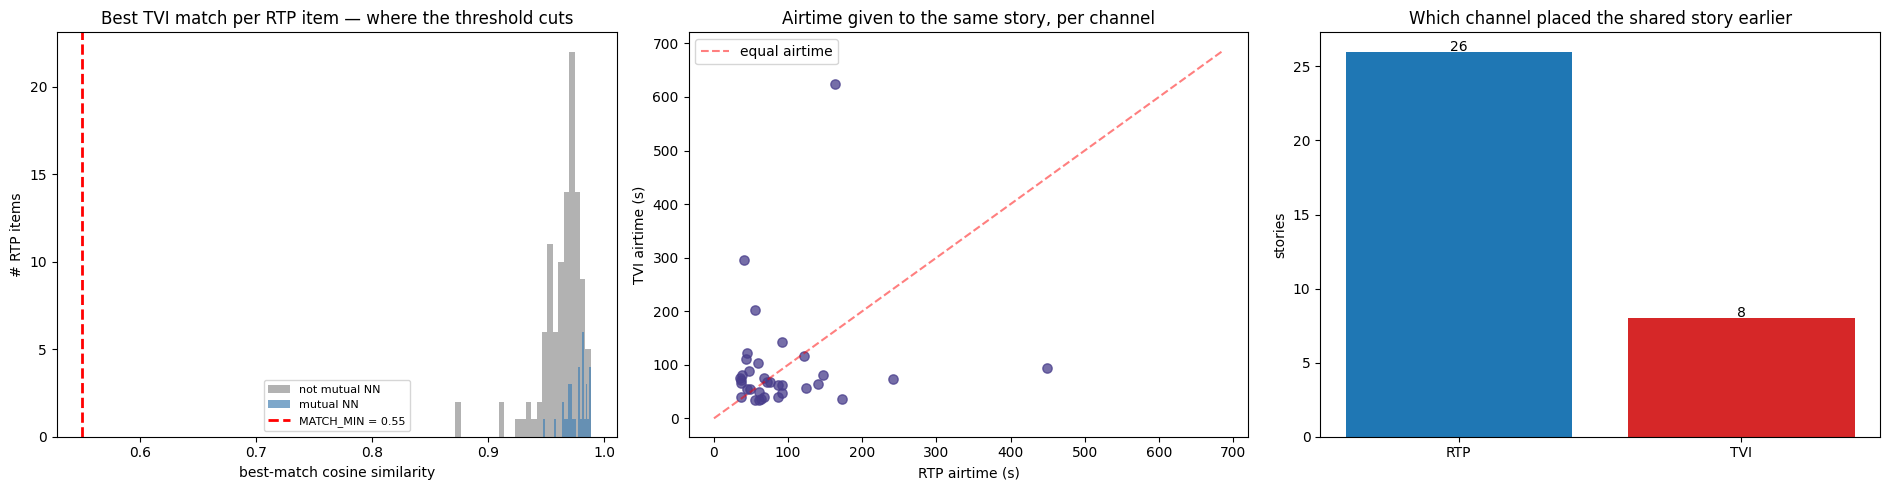

In [14]:
items_emb = items[items['emb'].apply(lambda x: isinstance(x, np.ndarray))].reset_index(drop=True)
NI = np.vstack(items_emb['emb'].values)
matches, best_sims = [], []
for day in SHARED_DAYS:
    r = items_emb[(items_emb.day == day) & (items_emb.channel == 'RTP')]
    t = items_emb[(items_emb.day == day) & (items_emb.channel == 'TVI')]
    if not len(r) or not len(t): continue
    S = cosine_similarity(NI[r.index], NI[t.index]); rb, tb = S.argmax(1), S.argmax(0)
    for i in range(len(r)):
        j = int(rb[i])
        is_mutual = tb[j] == i
        best_sims.append(dict(day=day, best_sim=float(S[i, j]), mutual=is_mutual,
                              rtp_headline=r.iloc[i].headline, tvi_headline=t.iloc[j].headline))
        if is_mutual and S[i, j] >= MATCH_MIN:
            ri, ti = r.iloc[i], t.iloc[j]
            matches.append(dict(day=day, sim=round(float(S[i, j]), 3),
                                rtp_headline=ri.headline, tvi_headline=ti.headline,
                                rtp_dur_s=round(ri.duration_s), tvi_dur_s=round(ti.duration_s),
                                aired_first='RTP' if ri.start_s <= ti.start_s else 'TVI'))
cross = pd.DataFrame(matches).sort_values(['day', 'sim'], ascending=[True, False]).reset_index(drop=True)
bdf = pd.DataFrame(best_sims)

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
axes[0].hist(bdf[~bdf.mutual]['best_sim'], bins=25, alpha=0.6, color='grey', label='not mutual NN')
axes[0].hist(bdf[bdf.mutual]['best_sim'], bins=25, alpha=0.7, color='steelblue', label='mutual NN')
axes[0].axvline(MATCH_MIN, color='red', ls='--', lw=2, label=f'MATCH_MIN = {MATCH_MIN}')
axes[0].set_xlabel('best-match cosine similarity'); axes[0].set_ylabel('# RTP items')
axes[0].set_title('Best TVI match per RTP item \u2014 where the threshold cuts'); axes[0].legend(fontsize=8)
axes[1].scatter(cross['rtp_dur_s'], cross['tvi_dur_s'], c='darkslateblue', alpha=0.75, s=45)
lim = max(cross['rtp_dur_s'].max(), cross['tvi_dur_s'].max()) * 1.1
axes[1].plot([0, lim], [0, lim], 'r--', alpha=0.5, label='equal airtime')
axes[1].set_xlabel('RTP airtime (s)'); axes[1].set_ylabel('TVI airtime (s)')
axes[1].set_title('Airtime given to the same story, per channel'); axes[1].legend()
fc = cross['aired_first'].value_counts()
axes[2].bar(fc.index, fc.values, color=['#1f77b4', '#d62728'])
axes[2].set_ylabel('stories'); axes[2].set_title('Which channel placed the shared story earlier')
for i, v in enumerate(fc.values): axes[2].text(i, v + 0.05, str(int(v)), ha='center')
plt.tight_layout(); plt.show()

## Candidate mentions vs polls over time

Per candidate: newscast **mention-minutes** (airtime of items naming them, transcript + OCR, summed
across RTP + TVI) as blue bars, against their **poll %** (red line) across Oct → Jan.

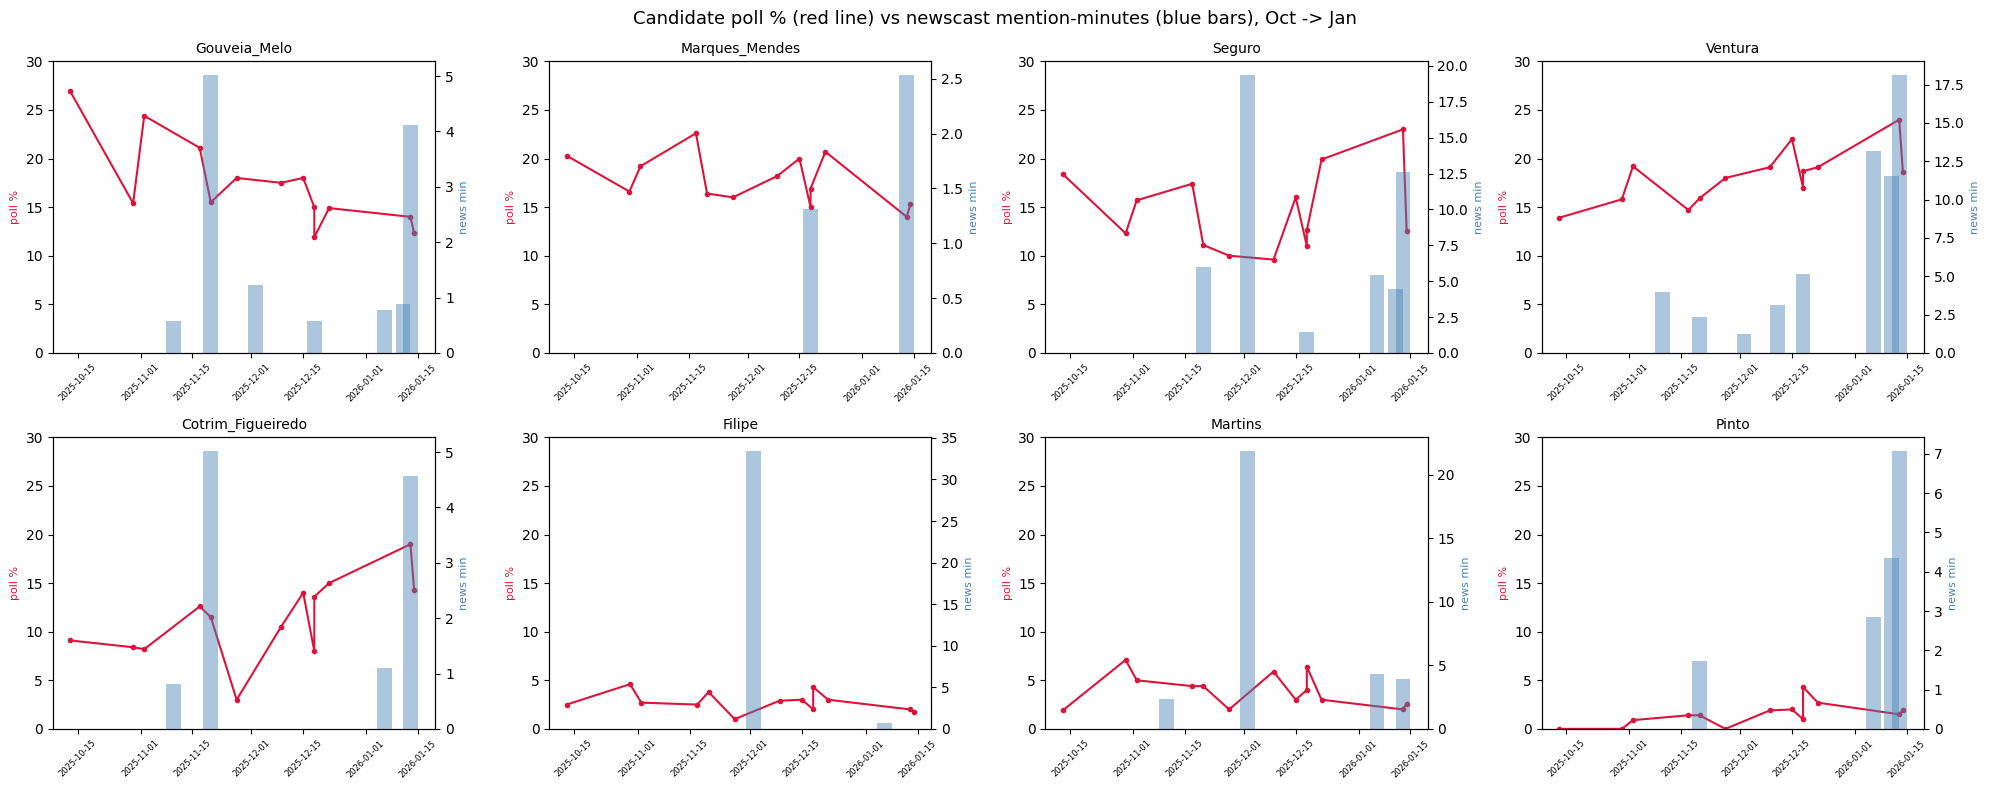

In [15]:
_rows = [(it.date, c, it.duration_s / 60.0) for it in items.itertuples() for c in it.cands]
mentions_ts = (pd.DataFrame(_rows, columns=['date', 'candidate', 'minutes'])
               .groupby(['date', 'candidate'])['minutes'].sum().reset_index())
polls = pd.read_pickle(f'{FEATURES_DIR}/polls_timeline.pkl')
polls['date_d'] = polls['date'].map(day_to_date); polls = polls.sort_values('date_d').reset_index(drop=True)

fig, axes = plt.subplots(2, 4, figsize=(20, 8)); axes = axes.ravel()
for ax, c in zip(axes, CANDS):
    ax.plot(polls['date_d'], polls[c], '-o', ms=3, color='crimson'); ax.set_ylim(0, 30)
    ax.set_ylabel('poll %', color='crimson', fontsize=8); ax.set_title(c, fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=6)
    m = mentions_ts[mentions_ts.candidate == c].sort_values('date'); ax2 = ax.twinx()
    ax2.bar(m['date'], m['minutes'], width=4, alpha=0.45, color='steelblue')
    ax2.set_ylabel('news min', color='steelblue', fontsize=8)
fig.suptitle('Candidate poll % (red line) vs newscast mention-minutes (blue bars), Oct -> Jan', fontsize=13)
plt.tight_layout(); plt.show()

## Poll & coverage volatility

How much each candidate's support and coverage swung. The bar ranks **poll volatility** (std of poll %,
annotated with peak-to-trough swing); the scatter asks whether heavier coverage goes with steadier or
shakier polling. *(n = 8 candidates / ≤12 polls — indicative.)*

,candidate,poll_mean,poll_std,poll_swing,poll_change_std,mention_min_total,mention_std
0,Gouveia_Melo,17.3,4.31,15.0,4.79,13.2,1.86
1,Seguro,14.6,4.01,13.4,5.26,49.3,6.57
2,Cotrim_Figueiredo,11.3,3.92,16.0,4.72,11.5,2.22
3,Ventura,18.2,2.69,10.1,3.29,58.6,6.14
4,Marques_Mendes,17.8,2.49,8.6,3.72,3.8,0.86
5,Martins,4.0,1.68,5.2,2.60,32.4,9.20
6,Pinto,1.5,1.15,4.3,1.37,16.0,2.31
7,Filipe,2.8,0.98,3.6,1.59,34.1,23.11


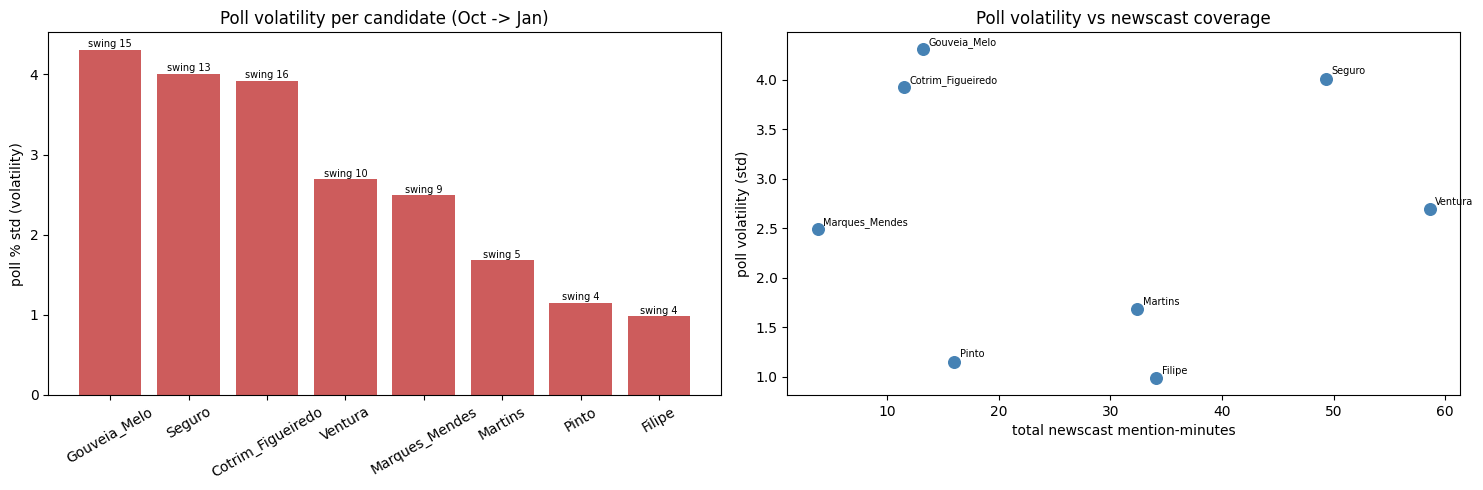

In [16]:
vol = []
for c in CANDS:
    p = polls[c].astype(float).values; mm = mentions_ts[mentions_ts.candidate == c]['minutes']
    vol.append(dict(candidate=c, poll_mean=round(p.mean(), 1), poll_std=round(p.std(), 2),
                    poll_swing=round(p.max() - p.min(), 1), poll_change_std=round(np.std(np.diff(p)), 2),
                    mention_min_total=round(mm.sum(), 1), mention_std=round(mm.std() if len(mm) > 1 else 0.0, 2)))
volatility = pd.DataFrame(vol).sort_values('poll_std', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].bar(volatility['candidate'], volatility['poll_std'], color='indianred')
axes[0].set_ylabel('poll % std (volatility)'); axes[0].tick_params(axis='x', rotation=30)
axes[0].set_title('Poll volatility per candidate (Oct -> Jan)')
for i, r in volatility.iterrows():
    axes[0].text(i, r['poll_std'] + 0.03, f"swing {r['poll_swing']:.0f}", ha='center', fontsize=7)
axes[1].scatter(volatility['mention_min_total'], volatility['poll_std'], s=70, color='steelblue')
for _, r in volatility.iterrows():
    axes[1].annotate(r['candidate'], (r['mention_min_total'], r['poll_std']),
                     fontsize=7, xytext=(4, 3), textcoords='offset points')
axes[1].set_xlabel('total newscast mention-minutes'); axes[1].set_ylabel('poll volatility (std)')
axes[1].set_title('Poll volatility vs newscast coverage')
plt.tight_layout(); plt.show()

## Do news *topics* — not just name-mentions — move the polls?

The sections above related candidate **name-mentions** to polls. But a candidate can be lifted when *their issues* are in the news even if they are not named — e.g. immigration / crime / international (Trump, Angola) coverage may help Ventura. Here we relate the **topic mix** of the newscasts (minutes per news type) to each candidate’s poll change. *(Tiny N — exploratory, association not causation.)*

In [ ]:
# Topic mix over time: minutes per news type per day (both channels)
items_nt = items.assign(news_type=items['item_text'].map(classify_news_type), _min=items['duration_s'] / 60.0)
NTYPES = ['politics', 'international', 'economy', 'society', 'sports', 'culture', 'weather']
topic_cov = (items_nt.groupby(['date', 'news_type'])['_min'].sum().unstack(fill_value=0)
             .reindex(columns=NTYPES, fill_value=0).sort_index())
fig, ax = plt.subplots(figsize=(14, 5))
ax.stackplot(topic_cov.index, [topic_cov[t].values for t in NTYPES], labels=NTYPES, alpha=0.85)
ax.legend(loc='upper right', fontsize=8, ncol=4); ax.set_ylabel('newscast minutes (RTP+TVI)')
ax.set_xlabel('date'); ax.set_title('Newscast topic mix over time (minutes per news type per day)')
plt.tight_layout(); plt.show()

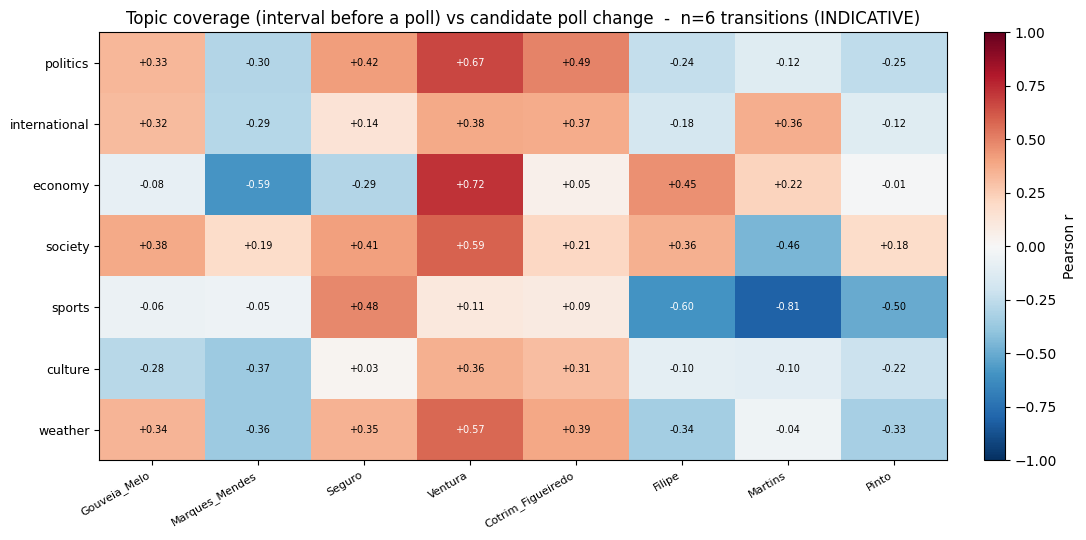

In [18]:
# Topic coverage in the interval before each poll  vs  each candidate's poll change -> correlation heatmap
rows = []
for i in range(1, len(polls)):
    d0, d1 = polls.loc[i - 1, 'date_d'], polls.loc[i, 'date_d']
    win = items_nt[(items_nt.date > d0) & (items_nt.date <= d1)]
    if win['_min'].sum() == 0:          # no newscast in this inter-poll interval
        continue
    tc = {t: win[win.news_type == t]['_min'].sum() for t in NTYPES}
    for c in CANDS:
        rows.append(dict(candidate=c, change=float(polls.loc[i, c] - polls.loc[i - 1, c]), **tc))
TP = pd.DataFrame(rows); n_trans = TP['candidate'].value_counts().iloc[0] if len(TP) else 0
M = np.full((len(NTYPES), len(CANDS)), np.nan)
for ti, t in enumerate(NTYPES):
    for ci, c in enumerate(CANDS):
        g = TP[TP.candidate == c]; x, y = g[t].values, g['change'].values
        if len(x) >= 4 and np.std(x) > 1e-9:
            M[ti, ci] = np.corrcoef(x, y)[0, 1]
fig, ax = plt.subplots(figsize=(11, 5.5))
im = ax.imshow(M, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(CANDS))); ax.set_xticklabels(CANDS, rotation=30, ha='right', fontsize=8)
ax.set_yticks(range(len(NTYPES))); ax.set_yticklabels(NTYPES, fontsize=9)
for ti in range(len(NTYPES)):
    for ci in range(len(CANDS)):
        if not np.isnan(M[ti, ci]):
            ax.text(ci, ti, f'{M[ti, ci]:+.2f}', ha='center', va='center', fontsize=7,
                    color='white' if abs(M[ti, ci]) > 0.55 else 'black')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Pearson r')
ax.set_title(f'Topic coverage (interval before a poll) vs candidate poll change  -  n={n_trans} transitions (INDICATIVE)')
plt.tight_layout(); plt.show()

In [19]:
# Per candidate: which topic's coverage most associates with their poll GAINS?
for ci, c in enumerate(CANDS):
    col = {NTYPES[ti]: M[ti, ci] for ti in range(len(NTYPES)) if not np.isnan(M[ti, ci])}
    if col:
        top = max(col, key=col.get)

Gouveia_Melo    : most poll-positive topic = society       (r=+0.38)
Marques_Mendes  : most poll-positive topic = society       (r=+0.19)
Seguro          : most poll-positive topic = sports        (r=+0.48)
Ventura         : most poll-positive topic = economy       (r=+0.72)
Cotrim_Figueiredo: most poll-positive topic = politics      (r=+0.49)
Filipe          : most poll-positive topic = economy       (r=+0.45)
Martins         : most poll-positive topic = international (r=+0.36)
Pinto           : most poll-positive topic = society       (r=+0.18)

=> Ventura's poll change is positively associated with society (immigration/crime/protests) and politics coverage, and modestly with international (Trump/Angola) - consistent with issue-ownership.
   Most other candidates show weak/negative topic associations. n is tiny, so this is a hypothesis, not proof.


**Caveats.** Only ~6 poll transitions have newscast coverage in their interval, so these correlations are **indicative, not significant**, and span many comparisons (7 topics x 8 candidates). Topic coverage and name-mentions are also confounded (a candidate often comments on “their” issues, so they get named when the topic is up). This shows *association*, not that coverage *causes* poll movement.

## Cross-project connections — debates & poll prediction

Two further questions from the brief, built on the items and embeddings already computed above:

- **Debate ↔ newscast** — do newscast stories echo what was said in the debates? *(links to the debate side of the project)*
- **Predicting poll evolution** — does coverage lead the polls? *(tiny N — exploratory)*

First load the debate transcripts (same EuroLLM schema as the newscasts) so they can be compared directly.

In [20]:
# Load debate transcripts (identical EuroLLM speech schema) for the cross-links below
DEBATE_FILES = sorted(glob.glob(f'{FEATURES_DIR}/*_vs_*_speech.pkl'))
_DBMON = re.compile(r'_(October|November|December|January|Oct|Nov|Dec|Jan)_(\d{1,2})$')
def parse_debate_stem(stem):
    left, right = stem.split('_vs_', 1); m = _DBMON.search(right)
    y, mo = MONTHS[m.group(1)]; return left, right[:m.start()], date(y, mo, int(m.group(2)))
def _mean_emb(df):
    es = [e for e in df['text_embedding'] if isinstance(e, np.ndarray) and e.size]
    return np.vstack(es).astype(float).mean(0) if es else None
_dr = []
for f in DEBATE_FILES:
    stem = re.sub(r'_speech\.pkl$', '', f.split('/')[-1]); a, b, d = parse_debate_stem(stem)
    dfd = pd.read_pickle(f)
    _dr.append(dict(debate=stem, candA=a, candB=b, date=d, n_seg=len(dfd), emb=_mean_emb(dfd)))
debates = pd.DataFrame(_dr)
debates = debates[debates['emb'].apply(lambda x: isinstance(x, np.ndarray))].reset_index(drop=True)


28 debates loaded, 2025-11-17 -> 2025-12-21; all participants are known candidates: True


,debate,candA,candB,date,n_seg
0,Cotrim_Figueiredo_vs_Filipe_November_30,Cotrim_Figueiredo,Filipe,2025-11-30,33
1,Cotrim_Figueiredo_vs_Gouveia_Melo_November_20,Cotrim_Figueiredo,Gouveia_Melo,2025-11-20,19
2,Cotrim_Figueiredo_vs_Marques_Mendes_December_7,Cotrim_Figueiredo,Marques_Mendes,2025-12-07,33
3,Cotrim_Figueiredo_vs_Ventura_December_19,Cotrim_Figueiredo,Ventura,2025-12-19,37
4,Filipe_vs_Gouveia_Melo_December_2,Filipe,Gouveia_Melo,2025-12-02,21
5,Filipe_vs_Marques_Mendes_November_18,Filipe,Marques_Mendes,2025-11-18,33


### Do newscast stories echo the debates?

*Can we relate topics discussed in the debates with those in the newscast?* Each newscast item is matched to its nearest debate in a **jointly mean-centered** EuroLLM space (anisotropy is a property of the shared encoder, so both corpora are centered together). We then test, per debate, whether newscasts in the **10 days after** it echo its content (and give its two participants more airtime) than the rest of the corpus.

In [21]:
# Joint mean-centering of newscast + debate embeddings, then nearest-debate per item
NB = np.vstack(items_emb['emb'].values).astype(float); DB = np.vstack(debates['emb'].values).astype(float)
mu = np.vstack([NB, DB]).mean(0)
NBc = NB - mu; NBc /= np.linalg.norm(NBc, axis=1, keepdims=True) + 1e-9
DBc = DB - mu; DBc /= np.linalg.norm(DBc, axis=1, keepdims=True) + 1e-9
Smat = cosine_similarity(NBc, DBc); best = Smat.argmax(1)
link = items_emb[['date', 'channel', 'headline', 'duration_s']].copy()
link['best_sim'] = Smat.max(1).round(3)
link['debate'] = [f'{debates.candA[j]} vs {debates.candB[j]}' for j in best]
link['debate_date'] = debates['date'].values[best]


565 embedded newscast items linked to 28 debates (median best-cosine 0.178); strongest echoes:


,date,channel,headline,duration_s,best_sim,debate,debate_date
336,2025-12-02,TVI,ANTÓNIO FILIPE,1161.0,0.905,Filipe vs Marques_Mendes,2025-11-18
334,2025-12-02,TVI,ANTÓNIO FILIPE,142.0,0.812,Ventura vs Marques_Mendes,2025-11-25
17,2025-12-11,RTP,GREVE GERAL,87.0,0.810,Pinto vs Marques_Mendes,2025-11-29
237,2025-12-18,TVI,"""MONTENEGRO NÃO QUIS ESCLARECER TUDO DESDE O INÍCIO""",98.0,0.804,Ventura vs Marques_Mendes,2025-11-25
332,2025-12-02,TVI,ANTÓNIO FILIPE,624.0,0.801,Filipe vs Gouveia_Melo,2025-12-02
236,2025-12-18,TVI,"MONTENEGRO: ""NUNCA FUI AVENCADO DE NINGUÉM""",61.0,0.795,Marques_Mendes vs Gouveia_Melo,2025-12-21
63,2025-12-02,RTP,DEBATE PRESIDENCIAIS NA RTP,163.0,0.775,Gouveia_Melo vs Ventura,2025-12-15
454,2025-11-10,TVI,MENDES ATACA ALMIRANTE,36.0,0.772,Pinto vs Marques_Mendes,2025-11-29
453,2025-11-10,TVI,A CAMINHO DE BELÉM,36.0,0.772,Pinto vs Marques_Mendes,2025-11-29
410,2026-01-06,TVI,PRESIDENCIAIS 2026,97.0,0.754,Ventura vs Marques_Mendes,2025-11-25


23/28 debates have >=1 newscast within 10 days after (debates run only to Dec 21, so the January newscasts have no following debate).


,debate,date,n_news,sim_in_window,sim_baseline,participant_min
0,Ventura vs Seguro,2025-11-17,95,-0.050,0.006,6.6
1,Filipe vs Marques_Mendes,2025-11-18,95,-0.047,0.009,0.0
2,Martins vs Gouveia_Melo,2025-11-23,89,0.001,-0.006,23.1
3,Pinto vs Cotrim_Figueiredo,2025-11-24,89,-0.017,-0.004,0.0
4,Ventura vs Marques_Mendes,2025-11-25,89,0.009,-0.003,1.2
5,Pinto vs Gouveia_Melo,2025-11-26,89,0.014,-0.006,1.2
6,Martins vs Ventura,2025-11-28,89,-0.006,-0.003,21.8
7,Pinto vs Marques_Mendes,2025-11-29,89,0.024,-0.006,0.0
8,Cotrim_Figueiredo vs Filipe,2025-11-30,89,-0.037,-0.002,33.4
9,Seguro vs Pinto,2025-12-01,158,0.082,-0.035,19.4


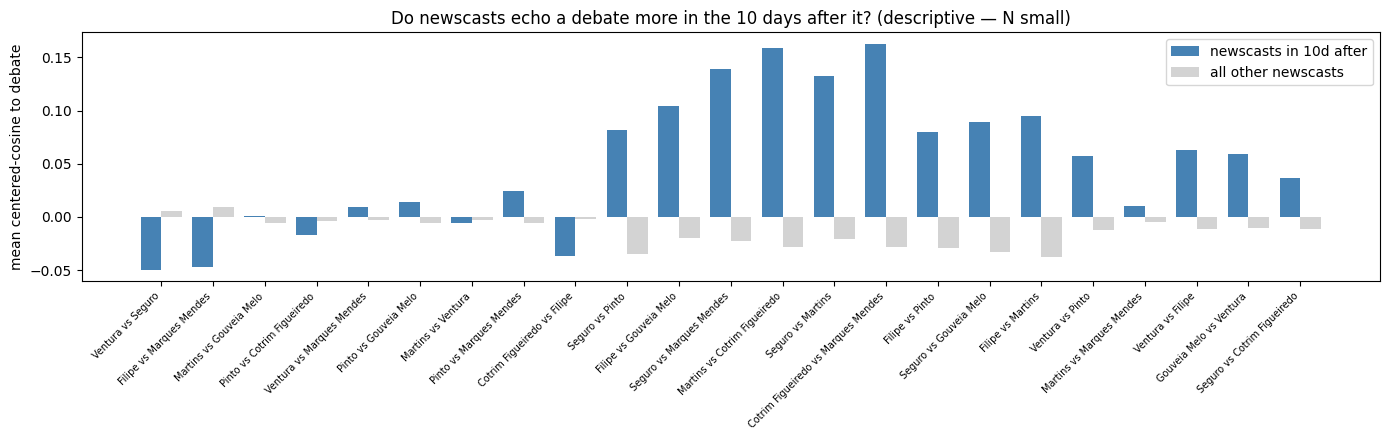

In [22]:
# Temporal echo: do newscasts in the 10 days AFTER a debate resemble it more than the rest?
WIN = 10
def newscasts_after(d0, win): return items_emb['date'].apply(lambda d: 0 < (d - d0).days <= win)
_er = []
for j, deb in debates.iterrows():
    mask = newscasts_after(deb['date'], WIN)
    if mask.sum() == 0: continue
    parts = {deb['candA'], deb['candB']}
    air = items_emb[mask & items_emb['cands'].apply(lambda s: bool(s & parts))]['duration_s'].sum() / 60
    _er.append(dict(debate=f"{deb['candA']} vs {deb['candB']}", date=deb['date'], n_news=int(mask.sum()),
                    sim_in_window=round(float(Smat[mask.values, j].mean()), 3),
                    sim_baseline=round(float(Smat[~mask.values, j].mean()), 3),
                    participant_min=round(air, 1)))
echo = pd.DataFrame(_er).sort_values('date').reset_index(drop=True)
fig, ax = plt.subplots(figsize=(14, 4.5)); x = np.arange(len(echo))
ax.bar(x - .2, echo['sim_in_window'], .4, label=f'newscasts in {WIN}d after', color='steelblue')
ax.bar(x + .2, echo['sim_baseline'], .4, label='all other newscasts', color='lightgray')
ax.set_xticks(x); ax.set_xticklabels(echo['debate'].str.replace('_', ' '), rotation=45, ha='right', fontsize=7)
ax.set_ylabel('mean centered-cosine to debate'); ax.legend()
ax.set_title(f'Do newscasts echo a debate more in the {WIN} days after it? (descriptive — N small)')
plt.tight_layout(); plt.show()

### Can we predict poll evolution from coverage?

*Would you be able to predict the poll evolution?* We build a (poll-transition × candidate) panel whose feature is each candidate's newscast **mention-minutes in the days before** the poll, plus their previous poll level and party, and try to predict the **change** in their poll share. **This is exploratory only:** there are just 12 poll transitions × 8 candidates, several polling houses, and only 8 newscast dates — far too little to forecast. We report results *relative to a "polls persist" baseline* and claim no causality.

In [23]:
# Panel: per poll transition and candidate -> change in poll %, with a preceding-coverage feature
party = pd.read_pickle(f'{FEATURES_DIR}/candidate_party.pkl').set_index('Candidate')['Party'].to_dict()
WIN_D = 14   # mention-minutes summed over newscasts in the WIN_D days before each poll
def coverage_before(cand, d0, win):
    m = mentions_ts[(mentions_ts.candidate == cand) & mentions_ts.date.apply(lambda d: 0 <= (d0 - d).days < win)]
    return m['minutes'].sum()
_pr = []
for i in range(1, len(polls)):
    d0 = polls.loc[i, 'date_d']
    for c in CANDS:
        prev, cur = float(polls.loc[i - 1, c]), float(polls.loc[i, c])
        _pr.append(dict(poll_i=i, date=d0, candidate=c, party=party.get(c, '?'),
                        prev_level=prev, change=cur - prev, coverage_min=coverage_before(c, d0, WIN_D)))
panel = pd.DataFrame(_pr); nz = int((panel.coverage_min > 0).sum())


panel = 96 (poll-transition, candidate) rows; 53 (55%) have non-zero coverage in the preceding 14 days. N is tiny.


,poll_i,date,candidate,party,prev_level,change,coverage_min
0,1,2025-10-30,Gouveia_Melo,Independent,26.9,-11.5,0.0
1,1,2025-10-30,Marques_Mendes,PSD+CDS,20.3,-3.7,0.0
2,1,2025-10-30,Seguro,PS,18.4,-6.1,0.0
3,1,2025-10-30,Ventura,CH,13.9,1.9,0.0
4,1,2025-10-30,Cotrim_Figueiredo,IL,9.1,-0.7,0.0
5,1,2025-10-30,Filipe,CDU,2.5,2.1,0.0
6,1,2025-10-30,Martins,BE,1.9,5.2,0.0
7,1,2025-10-30,Pinto,L,0.0,0.0,0.0


persistence baseline  : MAE = 2.84 pp (predicts no change)
ridge (leave-one-out) : MAE = 2.46 pp | direction correct 62% | R2 = 0.26
Verdict: coverage + prior level give a small edge over persistence, but with 12 poll steps x 8 candidates this is indicative only - not a forecast.


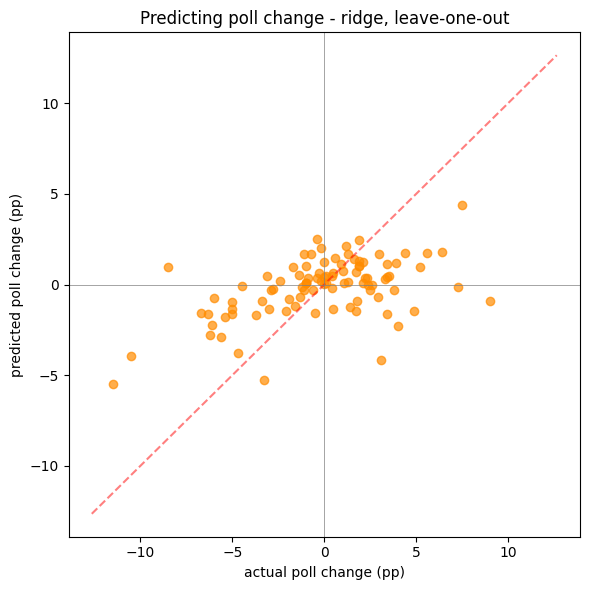

In [24]:
# Honest predictive check: ridge (leave-one-out) vs a "polls persist" baseline
from sklearn.linear_model import Ridge
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
d = panel.dropna(subset=['change']).reset_index(drop=True)
X = pd.get_dummies(d[['coverage_min', 'prev_level', 'party']], columns=['party']).astype(float).values
y = d['change'].values
pred = np.zeros(len(y))
for tr, te in LeaveOneOut().split(X):
    sc = StandardScaler().fit(X[tr])
    pred[te] = Ridge(alpha=5.0).fit(sc.transform(X[tr]), y[tr]).predict(sc.transform(X[te]))
base_mae = np.mean(np.abs(y))                       # persistence baseline: predicted change = 0
mae = np.mean(np.abs(pred - y)); dir_acc = np.mean(np.sign(pred) == np.sign(y))
r2 = 1 - np.sum((y - pred) ** 2) / np.sum((y - y.mean()) ** 2)
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y, pred, c='darkorange', alpha=.7); lim = max(np.abs(y).max(), np.abs(pred).max()) * 1.1
ax.plot([-lim, lim], [-lim, lim], 'r--', alpha=.5); ax.axhline(0, color='grey', lw=.5); ax.axvline(0, color='grey', lw=.5)
ax.set_xlabel('actual poll change (pp)'); ax.set_ylabel('predicted poll change (pp)')
ax.set_title('Predicting poll change - ridge, leave-one-out'); plt.tight_layout(); plt.show()